In [2]:
# Генератор данных, удаление шума, удаление периодического шума
# Метрики: SSIM, MSE. Сравните изображения.
# Изображения в оттенках серого.
# Задача 3.1
# Выполните фильтрацию изображений при  помощи преобразования Фурье.
# Сравните результаты фильтрации с алгоритмами, реализованными в task 1.
# Задача 3.2 
# Обновите генератор, который Вы создали в task_1.
# Добавьте деградационный периодический шум (покомпонентноее умножение исходного и зашумленного изображения). н
# Выполните фильтрацию периодического шума при  помощи преобразования Фурье. 
# Оцените качество фильтрации.

In [ ]:
# Задача 3.1

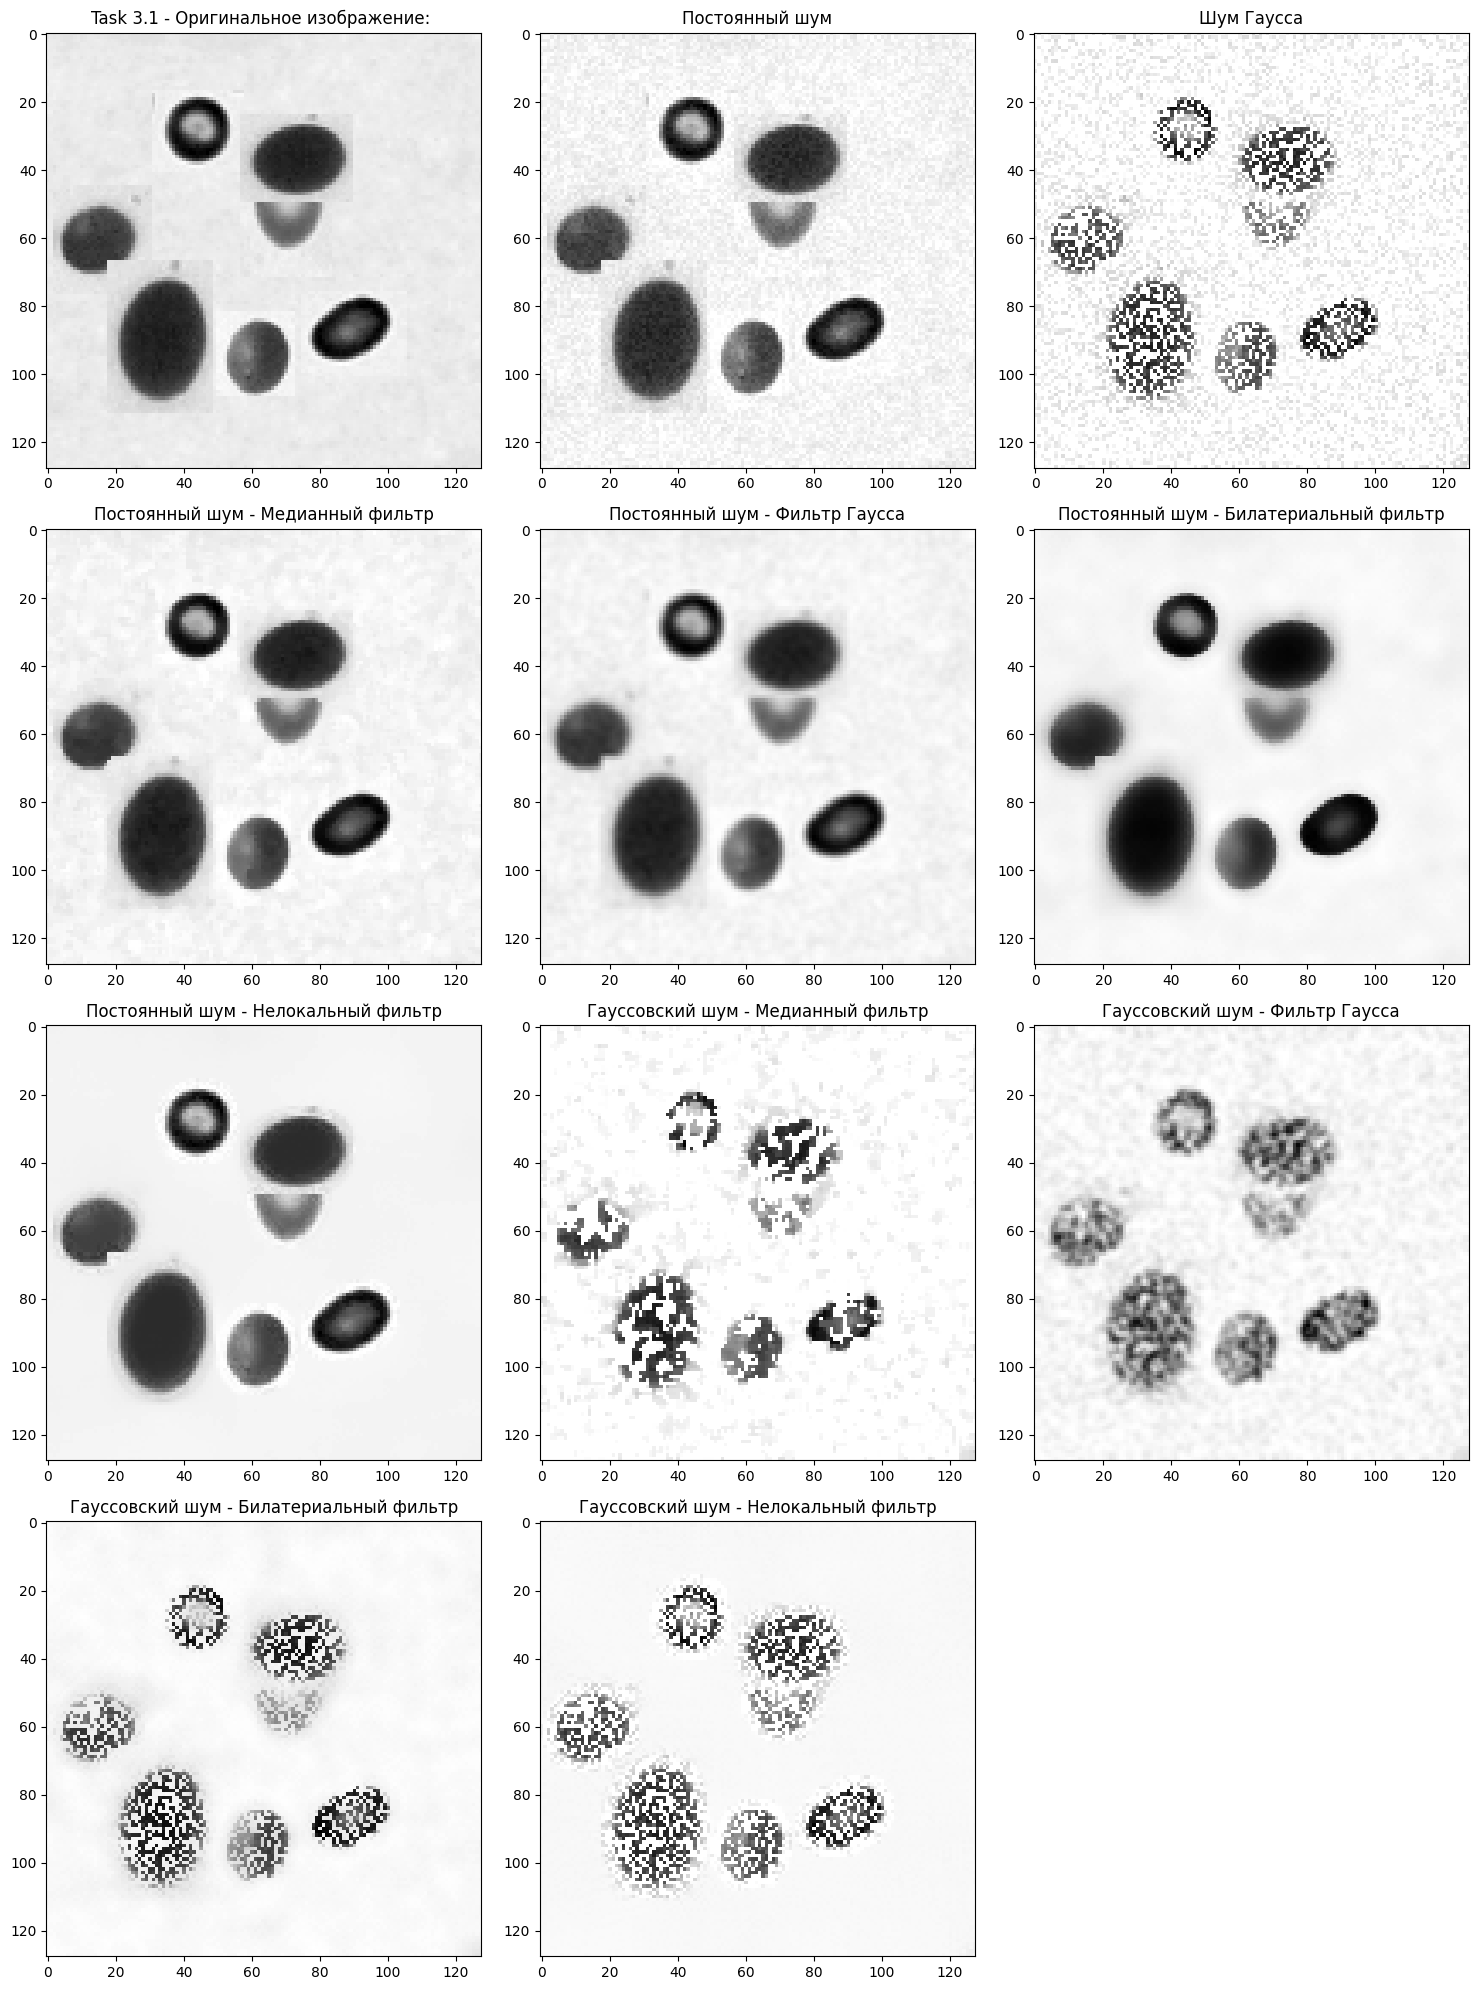


Метрики качества фильтрации для Task 3.1 - Оригинальное изображение:

Постоянный шум:
Медианный фильтр: MSE=405.50, SSIM=0.8934
Фильтр Гаусса: MSE=404.13, SSIM=0.9255
Билатериальный фильтр: MSE=422.05, SSIM=0.9074
Нелокальный фильтр: MSE=391.72, SSIM=0.9188

Лучший фильтр для постоянного шума: Нелокальный фильтр (MSE)



Гауссовский шум:
Медианный фильтр: MSE=3006.15, SSIM=0.5943
Фильтр Гаусса: MSE=2018.06, SSIM=0.7069
Билатериальный фильтр: MSE=2575.61, SSIM=0.7309
Нелокальный фильтр: MSE=2878.06, SSIM=0.7093

Лучший фильтр для гауссовского шума: Фильтр Гаусса (MSE)




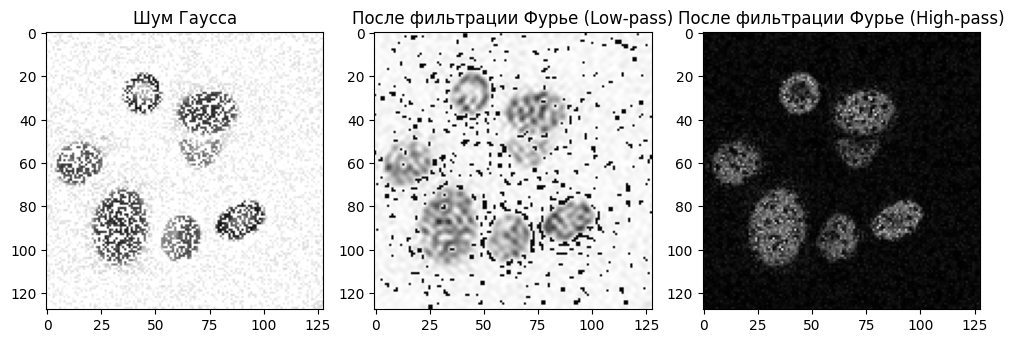

In [6]:
import os
import numpy as np
import cv2
import random
import time
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim, mean_squared_error
import math

fon_path = "/Users/zuhroabdulloeva/Desktop/4 КУРС/cv/blood_cells_dataset/fon/"
patch_path = "/Users/zuhroabdulloeva/Desktop/4 КУРС/cv/blood_cells_dataset/patch/"

fon_images = [cv2.imread(os.path.join(fon_path, f), cv2.IMREAD_GRAYSCALE) for f in os.listdir(fon_path) if f.endswith('.png')]
patch_images = [cv2.imread(os.path.join(patch_path, f), cv2.IMREAD_GRAYSCALE) for f in os.listdir(patch_path) if f.endswith('.png')]

def add_noise(image, noise_type="constant"):
    if noise_type == "constant":
        noise = np.random.randint(10, 30, image.shape, dtype=np.uint8)
        return cv2.add(image, noise)
    elif noise_type == "gaussian":
        mean = 0
        sigma = 25  # можно изменить на другие значения
        gauss = np.random.normal(mean, sigma, image.shape).astype(np.uint8)
        noisy = cv2.add(image, gauss)
        return noisy
    return image

def apply_filters_and_measure_time(image):
    filters = {}
    
    start_time = time.time()
    filters["Медианный фильтр"] = (cv2.medianBlur(image, 3), time.time() - start_time)

    start_time = time.time()
    filters["Фильтр Гаусса"] = (cv2.GaussianBlur(image, (3, 3), 0), time.time() - start_time)

    start_time = time.time()
    filters["Билатериальный фильтр"] = (cv2.bilateralFilter(image, 9, 75, 75), time.time() - start_time)

    start_time = time.time()
    filters["Нелокальный фильтр"] = (cv2.fastNlMeansDenoising(image, None, 10, 7, 21), time.time() - start_time)

    return filters

def fourier_filter(image, low_pass=True, cutoff_frequency=30):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)

    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2

    mask = np.zeros((rows, cols))
    if low_pass:
        mask[crow - cutoff_frequency:crow + cutoff_frequency, ccol - cutoff_frequency:ccol + cutoff_frequency] = 1
    else:
        mask[:crow - cutoff_frequency, :] = 1
        mask[crow + cutoff_frequency:, :] = 1
        mask[:, :ccol - cutoff_frequency] = 1
        mask[:, ccol + cutoff_frequency:] = 1

    fshift *= mask

    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    return np.uint8(img_back)

def evaluate_filters(original, noisy, filters):
    results = {}

    for name, (filtered, _) in filters.items():
        mse_value = mean_squared_error(original, filtered)
        min_dim = min(original.shape[:2]) 
        win_size = min(7, min_dim)  

        try:
            if win_size >= 7:
                ssim_value = ssim(original, filtered, full=True, win_size=win_size)[0]
            else:
                ssim_value = float('nan')
        except ValueError:
            ssim_value = float('nan')

        results[name] = (mse_value, ssim_value)

    return results

def generate_image():
    background = random.choice(fon_images).copy()
    image = background.copy()

    for _ in range(random.randint(5, 15)):  
        cell = random.choice(patch_images)
        cell = cv2.resize(cell, (random.randint(20, 50), random.randint(20, 50)))
        angles = [cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE]
        cell = cv2.rotate(cell, random.choice(angles))

        x_offset = random.randint(0, background.shape[1] - cell.shape[1])
        y_offset = random.randint(0, background.shape[0] - cell.shape[0])

        image[y_offset:y_offset+cell.shape[0], x_offset:x_offset+cell.shape[1]] = cell

    noisy_image_constant = add_noise(image, "constant")
    noisy_image_gaussian = add_noise(image, "gaussian")
    
    filtered_images_constant = apply_filters_and_measure_time(noisy_image_constant)
    filtered_images_gaussian = apply_filters_and_measure_time(noisy_image_gaussian)
    
    evaluation_constant = evaluate_filters(image, noisy_image_constant, filtered_images_constant)
    evaluation_gaussian = evaluate_filters(image, noisy_image_gaussian, filtered_images_gaussian)

    cv2.imwrite('image.png', image)  
    
    return image, noisy_image_constant, noisy_image_gaussian, filtered_images_constant, filtered_images_gaussian, evaluation_constant, evaluation_gaussian

def visualize_results(original, noisy_constant, noisy_gaussian, filtered_images_constant, filtered_images_gaussian, title, task):
    num_filters = len(filtered_images_constant) + len(filtered_images_gaussian) + 3
    rows = math.ceil(num_filters / 3)
    cols = min(num_filters, 3)

    plt.figure(figsize=(cols * 5, rows * 5))

    plt.subplot(rows, cols, 1)
    plt.imshow(original, cmap='gray')
    plt.title(f"{task} - {title}: ")

    plt.subplot(rows, cols, 2)
    plt.imshow(noisy_constant, cmap='gray')
    plt.title("Постоянный шум")

    plt.subplot(rows, cols, 3)
    plt.imshow(noisy_gaussian, cmap='gray')
    plt.title("Шум Гаусса")

    i = 4
    for name, (filtered, _) in filtered_images_constant.items():
        plt.subplot(rows, cols, i)
        plt.imshow(filtered, cmap='gray')
        plt.title(f"Постоянный шум - {name}")
        i += 1

    for name, (filtered, _) in filtered_images_gaussian.items():
        plt.subplot(rows, cols, i)
        plt.imshow(filtered, cmap='gray')
        plt.title(f"Гауссовский шум - {name}")
        i += 1

    plt.tight_layout()
    plt.show()

def print_results(evaluation_constant, evaluation_gaussian, title, task):
    print(f"\nМетрики качества фильтрации для {task} - {title}:")

    print("\nПостоянный шум:")
    best_constant_filter = min(evaluation_constant, key=lambda x: evaluation_constant[x][0])
    for name, (mse_val, ssim_val) in evaluation_constant.items():
        print(f"{name}: MSE={mse_val:.2f}, SSIM={ssim_val:.4f}")
    print()
    print(f"Лучший фильтр для постоянного шума: {best_constant_filter} (MSE)")
    print()
    print()

    print("\nГауссовский шум:")
    best_gaussian_filter = min(evaluation_gaussian, key=lambda x: evaluation_gaussian[x][0])
    for name, (mse_val, ssim_val) in evaluation_gaussian.items():
        print(f"{name}: MSE={mse_val:.2f}, SSIM={ssim_val:.4f}")
    print()
    print(f"Лучший фильтр для гауссовского шума: {best_gaussian_filter} (MSE)")
    print()
    print()

def main():
    task_3_1_title = "Task 3.1"
    original, noisy_constant, noisy_gaussian, filtered_constant, filtered_gaussian, evaluation_constant, evaluation_gaussian = generate_image()

    noisy_fourier = fourier_filter(noisy_gaussian, low_pass=True, cutoff_frequency=30)
    noisy_fourier_highpass = fourier_filter(noisy_gaussian, low_pass=False, cutoff_frequency=30)

    visualize_results(original, noisy_constant, noisy_gaussian, filtered_constant, filtered_gaussian, "Оригинальное изображение", task_3_1_title)
    print_results(evaluation_constant, evaluation_gaussian, "Оригинальное изображение", task_3_1_title)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(noisy_gaussian, cmap='gray')
    plt.title("Шум Гаусса")

    plt.subplot(1, 3, 2)
    plt.imshow(noisy_fourier, cmap='gray')
    plt.title("После фильтрации Фурье (Low-pass)")

    plt.subplot(1, 3, 3)
    plt.imshow(noisy_fourier_highpass, cmap='gray')
    plt.title("После фильтрации Фурье (High-pass)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
# Задача 3.2 

Изображение успешно загружено из: /Users/zuhroabdulloeva/Desktop/4 КУРС/cv/image.png


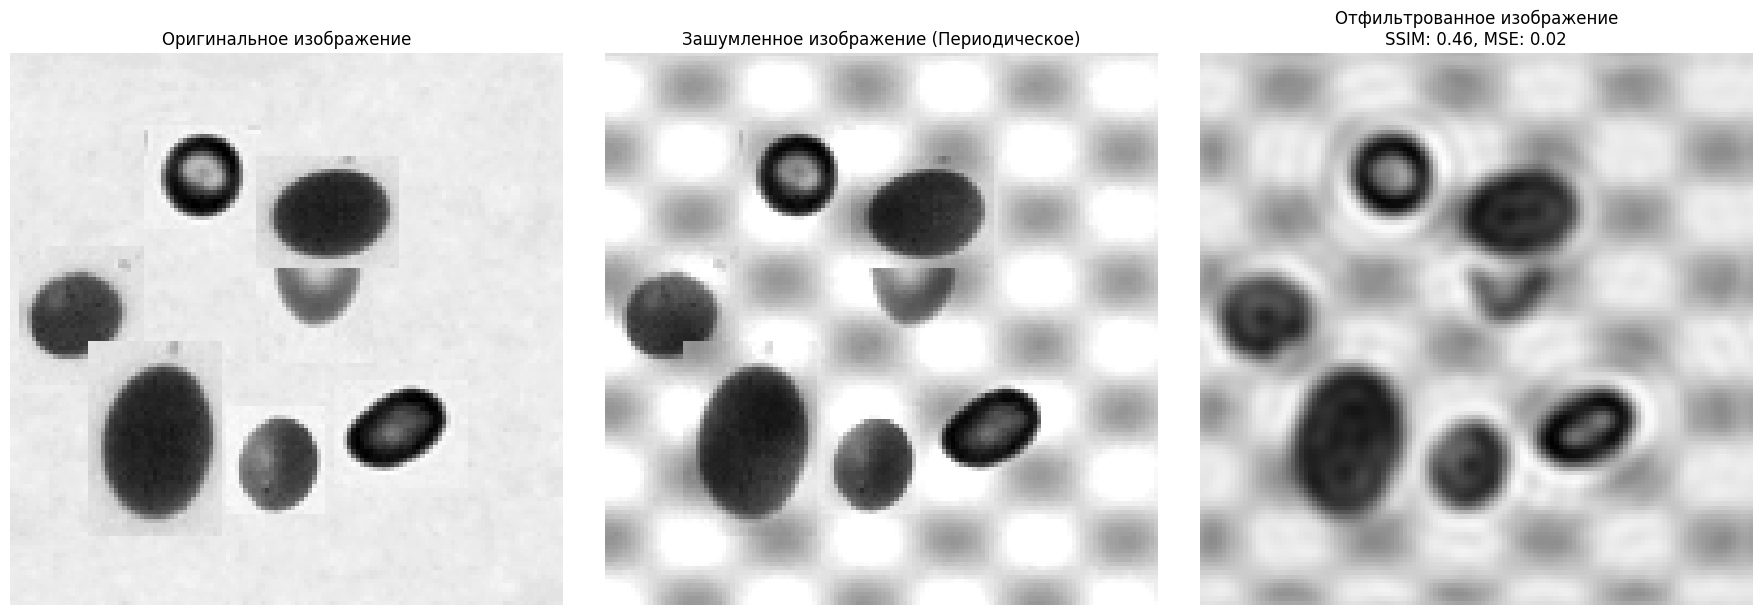

SSIM (Отфильтрованное): 0.46
MSE (Отфильтрованное): 0.02


In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse
from skimage import img_as_float
import os

config = {
    "noise_amplitude": 0.3, 
    "noise_frequency": (30, 40),  
    "low_pass_radius": 20,  
    "image_size": (512, 512), 
}

def add_periodic_noise(image, amplitude=0.1, frequency=(30, 40)):
    rows, cols = image.shape
    noise = np.zeros((rows, cols), dtype=np.float32)
    
    for i in range(rows):
        for j in range(cols):
            noise[i, j] = amplitude * np.sin(2 * np.pi * i / frequency[0]) * np.cos(2 * np.pi * j / frequency[1])
    
    image_float = image.astype(np.float32) / 255.0 
    noisy_image = image_float * (1 + noise)  
    noisy_image = np.clip(noisy_image, 0, 1)  
    return (noisy_image * 255).astype(np.uint8)  

def apply_low_pass_filter(image, radius=50):
    image_float = img_as_float(image)  
    f = np.fft.fft2(image_float)  
    fshift = np.fft.fftshift(f) 
    
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2 
    
    mask = np.zeros((rows, cols), np.uint8)  
    cv2.circle(mask, (ccol, crow), radius, 1, -1)  
    
    fshift_filtered = fshift * mask  
    f_ishift = np.fft.ifftshift(fshift_filtered) 
    img_back = np.fft.ifft2(f_ishift)  
    img_back = np.abs(img_back) 
    
    img_back = (img_back - img_back.min()) / (img_back.max() - img_back.min())  
    return (img_back * 255).astype(np.uint8)  

def calculate_metrics(original, filtered):
    original_float = img_as_float(original)
    filtered_float = img_as_float(filtered)
    ssim_value = ssim(original_float, filtered_float, data_range=1.0)  
    mse_value = mse(original_float, filtered_float)  
    return ssim_value, mse_value

image_path = os.path.join(os.getcwd(), 'image.png')  
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) 

if image is None:
    print(f"Ошибка при загрузке изображения: {image_path}")
else:
    print(f"Изображение успешно загружено из: {image_path}")

def main():
    original_image = image.astype(np.uint8) 

    noisy_image = add_periodic_noise(original_image, amplitude=config["noise_amplitude"], frequency=config["noise_frequency"])

    filtered_image = apply_low_pass_filter(noisy_image, radius=config["low_pass_radius"])

    ssim_value, mse_value = calculate_metrics(original_image, filtered_image)

    fig_images, axes_images = plt.subplots(1, 3, figsize=(18, 6))
    axes_images[0].imshow(original_image, cmap='gray')
    axes_images[0].set_title("Оригинальное изображение")
    axes_images[0].axis('off')

    axes_images[1].imshow(noisy_image, cmap='gray')
    axes_images[1].set_title("Зашумленное изображение (Периодическое)")
    axes_images[1].axis('off')

    axes_images[2].imshow(filtered_image, cmap='gray')
    axes_images[2].set_title(f"Отфильтрованное изображение\nSSIM: {ssim_value:.2f}, MSE: {mse_value:.2f}")
    axes_images[2].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"SSIM (Отфильтрованное): {ssim_value:.2f}")
    print(f"MSE (Отфильтрованное): {mse_value:.2f}")

if __name__ == "__main__":
    main()